# Download datasets and importing necessary libraries

In [ ]:
!gdown --id 1219EeGE1XTJVXYaulynJSa3BXGsbNCLx

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=fcddda48-4088-4ed7-88b0-dab4baa1fd0c
To: /content/Archive.zip
100% 1.23G/1.23G [00:27<00:00, 44.4MB/s]


In [ ]:
import os

print(os.listdir())

['.config', 'Archive.zip', 'sample_data']


In [35]:
import zipfile

zip_file = 'Archive.zip'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [ ]:
import os

for root, dirs, files in os.walk('dataset'):
    print(root)
    break

dataset


In [ ]:
print(os.listdir('dataset'))

['test', 'train', '__MACOSX', 'val']


# Reorganize the datasets

In [36]:
import os
import shutil

base_path = 'dataset'
fixed_path = 'dataset_fixed'

os.makedirs(fixed_path, exist_ok=True)

splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(fixed_path, split, cls), exist_ok=True)

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(('.jpeg', '.jpg', '.png')):

            full_path = os.path.join(root, file)

            if 'NORMAL' in root.upper():
                cls = 'NORMAL'
            elif 'PNEUMONIA' in root.upper():
                cls = 'PNEUMONIA'
            else:
                continue

            if 'TRAIN' in root.upper():
                split = 'train'
            elif 'VAL' in root.upper():
                split = 'val'
            elif 'TEST' in root.upper():
                split = 'test'
            else:
                continue

            dest = os.path.join(fixed_path, split, cls, file)

            try:
                shutil.copy(full_path, dest)
            except:
                pass

print(" Fixed dataset ready!")

 Fixed dataset ready!


In [ ]:
for folder in ['train','val','test']:
    print("\n", folder)
    for sub in os.listdir('dataset_fixed/' + folder):
        print(sub, "->", len(os.listdir('dataset_fixed/' + folder + '/' + sub)))


 train
NORMAL -> 1341
PNEUMONIA -> 3875

 val
NORMAL -> 8
PNEUMONIA -> 8

 test
NORMAL -> 234
PNEUMONIA -> 390


In [ ]:
train_dir = 'dataset_fixed/train'
val_dir   = 'dataset_fixed/val'
test_dir  = 'dataset_fixed/test'

# Image Data Generation, Augmentation, Pre-processing and Model Training

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models

IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = keras.Sequential([

    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.7586 - loss: 0.5041 - val_accuracy: 0.8125 - val_loss: 0.5155
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.8495 - loss: 0.3252 - val_accuracy: 0.7500 - val_loss: 0.6176
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.8901 - loss: 0.2608 - val_accuracy: 0.8125 - val_loss: 0.3997
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9093 - loss: 0.2355 - val_accuracy: 0.8125 - val_loss: 0.4932
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9237 - loss: 0.2011 - val_accuracy: 0.8750 - val_loss: 0.5421
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9296 - loss: 0.1856 - val_accuracy: 0.8125 - val_loss: 0.5690
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.9360 - loss: 0.1678 - val_accuracy: 0.6875 - val_loss: 0.6714
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9413 - loss: 0.1548 - val_accuracy: 0.812

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 592ms/step - accuracy: 0.8077 - loss: 0.6072
Test Accuracy: 80.77%


In [17]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    'dataset/val',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Visualization of sample images

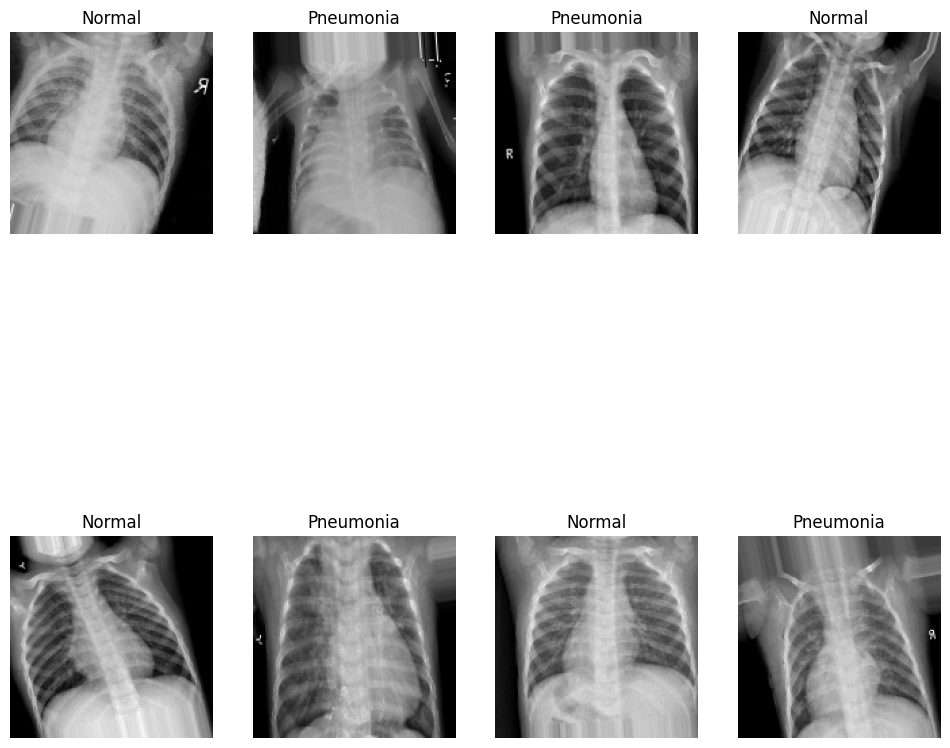

In [18]:
def plot_samples(generator):
    images, labels = next(generator)

    plt.figure(figsize=(12, 12))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])

        label = "Pneumonia" if labels[i] == 1 else "Normal"
        plt.title(label)
        plt.axis('off')
    plt.show()

plot_samples(train_generator)

# Class Distribution

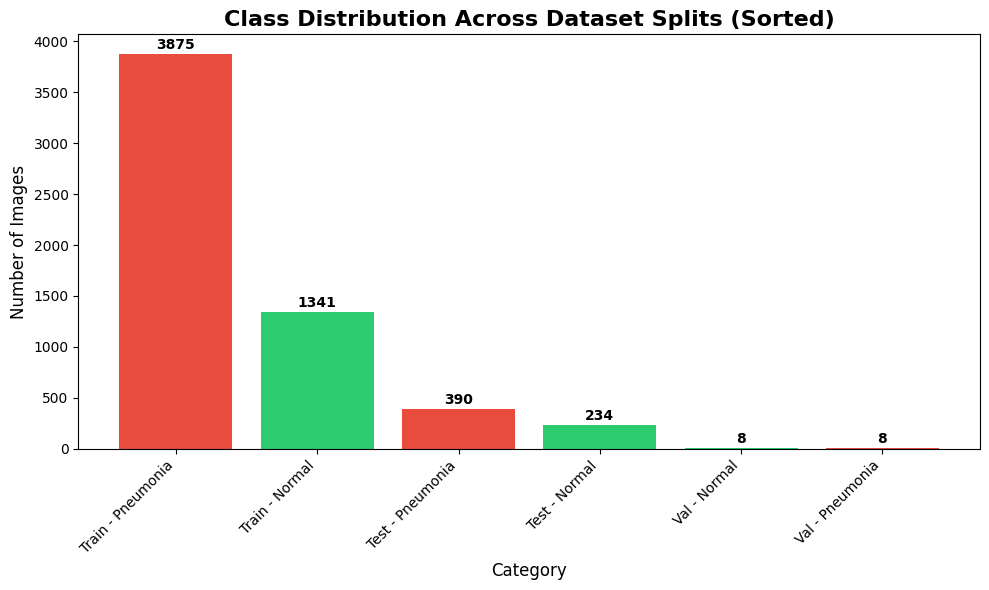

In [19]:
import os
import matplotlib.pyplot as plt

base_dir = 'dataset'

splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

distribution = {}

for split in splits:
    for cls in classes:
        folder_path = os.path.join(base_dir, split, cls)
        if os.path.exists(folder_path):
            count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
            key_name = f"{split.capitalize()} - {cls.capitalize()}"
            distribution[key_name] = count

sorted_distribution = dict(sorted(distribution.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(10, 6))

colors = ['#e74c3c' if 'Pneumonia' in k else '#2ecc71' for k in sorted_distribution.keys()]

bars = plt.bar(sorted_distribution.keys(), sorted_distribution.values(), color=colors)

plt.title('Class Distribution Across Dataset Splits (Sorted)', fontsize=16, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, f'{yval}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Evaluation of test data

In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating on test data...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}\n")

y_true = test_generator.classes

y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

Evaluating on test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 664ms/step - accuracy: 0.6250 - loss: 0.7930

Test Accuracy: 62.50%
Test Loss: 0.7930

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 649ms/step


# Model Evaluation

In [32]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import metrics

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(),
        metrics.Recall(),
        metrics.AUC()
    ]
)

print("Evaluating on test data...")
results = model.evaluate(test_generator, verbose=1)

print(f"\nTest Accuracy  : {results[1]:.4f}")
print(f"Test Precision : {results[2]:.4f}")
print(f"Test Recall    : {results[3]:.4f}")
print(f"Test AUC       : {results[4]:.4f}")

precision = results[2]
recall = results[3]

if (precision + recall) == 0:
    f1_score = 0.0
else:
    f1_score = 2 * (precision * recall) / (precision + recall)
print(f"Test F1 Score  : {f1_score:.4f}")

y_true = test_generator.classes

y_pred_prob = model.predict(test_generator)

y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

Evaluating on test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 659ms/step - accuracy: 0.6250 - auc_3: 0.2226 - loss: 0.7930 - precision_3: 0.6250 - recall_3: 1.0000

Test Accuracy  : 0.6250
Test Precision : 0.6250
Test Recall    : 1.0000
Test AUC       : 0.2226
Test F1 Score  : 0.7692
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 605ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



# Confusion Matrix

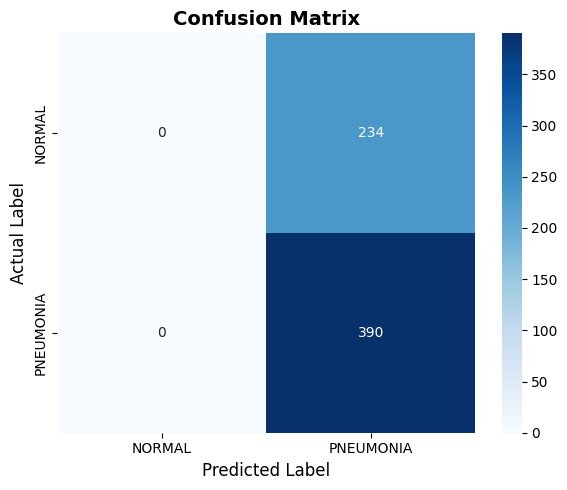

In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Final model performance summary

In [34]:
print("=" * 50)
print("        FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 50)

print(f"Accuracy    : {results[1]:.4f}")
print(f"Precision   : {results[2]:.4f}")
print(f"Recall      : {results[3]:.4f}")
print(f"AUC         : {results[4]:.4f}")

print(f"F1 Score    : {f1_score:.4f}")

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

sensitivity = results[3]

if (TN + FP) == 0:
    specificity = 0.0
else:
    specificity = TN / (TN + FP)

roc_auc = results[4]

print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"ROC AUC     : {roc_auc:.4f}")

print("=" * 50)

        FINAL MODEL PERFORMANCE SUMMARY
Accuracy    : 0.6250
Precision   : 0.6250
Recall      : 1.0000
AUC         : 0.2226
F1 Score    : 0.7692
Sensitivity : 1.0000
Specificity : 0.0000
ROC AUC     : 0.2226
